## CITS2402 – Introduction to Data Science – Project

### Industry Structure and Workforce Qualifications in Australia and New Zealand

**Census data:** Australia 2021 and New Zealand 2023  
**Date:** 2 October 2026


## Declaration

We are aware of the University's policy on academic conduct and declare that this assignment is entirely the work of the authors listed below. Suitable acknowledgement has been made for all sources used, and we have retained a copy for our own records.

- Name 1: Goh Zi Rong
- Student ID 1: 25174009
- Name 2: Justin Seow
- Student ID 2: 24754702
- Name 3: Nira Ram Racheya
- Student ID 3: 25305007
- Date: 2 October 2026


## 1. Introduction and research question

A country's workforce can differ in two related ways: **where people work** and **what qualifications they hold**. Looking at both together gives a more useful comparison than simply asking which country has more degree holders.

This project compares Australia's 2021 Census with New Zealand's 2023 Census across the same 19 industry divisions.

### Research question

> **How do post-school qualification profiles differ across Australian and New Zealand industries, and are the overall differences mainly explained by the countries having different industry mixes, or by workers having different qualification levels within the same industries?**

We answer this in stages:

1. Compare the **industry mix** of workers with post-school qualifications.
2. Compare qualification profiles **within each industry**.
3. Summarise the 19 industries into four broad sectors.
4. Split the national qualification gap into an **industry-mix effect** and a **within-industry effect**.
5. Test whether the result changes when New Zealand Level 3 certificates are classified differently.
6. Extend the analysis to the **whole workforce**, including workers with no post-school qualification.

Because census data is a snapshot, the analysis describes **associations**, not cause and effect.


## 2. Data and provenance

We use official census data from the Australian Bureau of Statistics (ABS) and Stats NZ.

| | Australia | New Zealand |
|---|---|---|
| Source | Australian Bureau of Statistics (ABS) | Stats NZ, Aotearoa Data Explorer |
| Census | 2021 | 2023 |
| Main table | GCP **G53A–G53C**: non-school qualification by industry and sex | **CEN23_EDU_003**: highest qualification, industry and gender |
| Unit | Employed persons aged 15+ | Employed census usually resident population aged 15+ |
| Files | `2021Census_G53A_AUS_AUS.csv`, `...G53B...`, `...G53C...` | `STATSNZ_CEN23_EDU_003_1_0_2023_9999___99.csv` |

Section 7 also uses ABS **G54A–G54D**, which gives total employed persons by industry and age. This lets us estimate the Australian group with **no post-school qualification**.

### How the data was obtained

**Australia:** ABS → Census → Find Census data → Census data tools → DataPacks → select **2021**, geography **Australia**, and **General Community Profile**. The metadata spreadsheet identifies G53 as the industry-by-qualification table and G54 as the employed-persons-by-industry table.

**New Zealand:** Stats NZ → Aotearoa Data Explorer → 2023 Census → search for **“Highest qualification, industry, and gender”** (`CEN23_EDU_003`) → select New Zealand total, all relevant industry and qualification categories, and export as CSV.

### Differences we need to account for

- **Different census years:** Australia 2021 and New Zealand 2023.
- **Different qualification systems:** ABS G53 contains non-school qualifications only, while the NZ table also includes school-level and no-qualification categories.
- **Confidentiality adjustments:** ABS perturbs small counts and Stats NZ rounds counts. At the national level used here, these differences are very small.

These differences are handled explicitly in the cleaning and sensitivity checks below.


In [9]:
# ---- Libraries ---------------------------------------------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---- Input files (must be in the same folder as this notebook) ----------------
ABS_FILES = [
    "2021Census_G53A_AUS_AUS.csv",
    "2021Census_G53B_AUS_AUS.csv",
    "2021Census_G53C_AUS_AUS.csv",
]
NZ_FILE = "STATSNZ_CEN23_EDU_003_1_0_2023_9999___99.csv"

COUNTRIES = ["Australia", "New Zealand"]

## 3. Making the two censuses comparable

Before comparing the countries, the industry and qualification labels need to mean roughly the same thing.

### Industries

Both censuses use the same 19 ANZSIC industry divisions. The names differ slightly in places, so the code maps them to one common label. Catch-all categories such as “not stated” and “not elsewhere included” are excluded.

### Qualifications

We group the two qualification systems into four comparable categories:

| Harmonised group | Australia (ABS) | New Zealand |
|---|---|---|
| Postgraduate | Postgraduate degree | Masters, Doctorate |
| Bachelor & related | Bachelor; Graduate diploma/certificate | Bachelor/Level 7; Post-graduate and honours |
| Diploma | Advanced diploma/Diploma | Level 5 and Level 6 diploma |
| Certificate | Certificate I–IV | Level 4 certificate |

The most uncertain match is **Certificate**. Australia combines Certificates I–IV, while our main NZ mapping keeps Level 4 only. NZ Levels 1–3 contain qualifications that do not line up neatly with the ABS category, so we do not pretend there is one perfect conversion. Section 6 deliberately changes this assumption to see whether the conclusions survive.

For Sections 4–6, categories with no comparable ABS equivalent are left out. This means those sections describe **workers with a post-school qualification**, not the entire workforce.

We also use **Bachelor-level or higher** (Postgraduate + Bachelor & related) as a broad indicator because these categories are more closely matched across the two systems.

### Broad sectors

For a simpler view of economic structure, the 19 industries are also grouped into four broad sectors. This grouping is our own analytical choice and is defined explicitly in the code so it can be inspected or changed.


In [10]:
# Master table: (short label, ABS column code, NZ label, broad sector)
INDUSTRIES = [
    ("Agriculture, Forestry & Fishing", "AgriForestFish", "Agriculture, Forestry and Fishing", "Primary & resources"),
    ("Mining", "Min", "Mining", "Primary & resources"),
    ("Manufacturing", "Mnfg", "Manufacturing", "Industrial & construction"),
    ("Electricity, Gas, Water & Waste", "EGW_WS", "Electricity, Gas, Water and Waste Services", "Industrial & construction"),
    ("Construction", "Cnstn", "Construction", "Industrial & construction"),
    ("Wholesale Trade", "WTrade", "Wholesale Trade", "Trade, transport & other services"),
    ("Retail Trade", "RTrade", "Retail Trade", "Trade, transport & other services"),
    ("Accommodation & Food", "AccomFoodS", "Accommodation and Food Services", "Trade, transport & other services"),
    ("Transport, Postal & Warehousing", "TransPostWhse", "Transport, Postal and Warehousing", "Trade, transport & other services"),
    ("Information Media & Telecom", "InfoMedTelecom", "Information Media and Telecommunications", "Knowledge-intensive services"),
    ("Financial & Insurance", "FinInsurS", "Financial and Insurance Services", "Knowledge-intensive services"),
    ("Rental, Hiring & Real Estate", "RentHirREserv", "Rental, Hiring and Real Estate Services", "Trade, transport & other services"),
    ("Professional, Scientific & Technical", "ProScieTechServ", "Professional, Scientific and Technical Services", "Knowledge-intensive services"),
    ("Administrative & Support", "AdminSupServ", "Administrative and Support Services", "Trade, transport & other services"),
    ("Public Admin & Safety", "PubAdmiSafety", "Public Administration and Safety", "Knowledge-intensive services"),
    ("Education & Training", "EducTrain", "Education and Training", "Knowledge-intensive services"),
    ("Health Care & Social Assistance", "HealthCareSocA", "Health Care and Social Assistance", "Knowledge-intensive services"),
    ("Arts & Recreation", "ArtRecServ", "Arts and Recreation Services", "Trade, transport & other services"),
    ("Other Services", "OthServ", "Other Services", "Trade, transport & other services"),
]
ABS_IND = {abs_code: label for label, abs_code, _, _ in INDUSTRIES}   # ABS column code -> label
NZ_IND = {nz_name: label for label, _, nz_name, _ in INDUSTRIES}     # NZ industry name -> label
SECTOR = {label: sector for label, _, _, sector in INDUSTRIES}        # label -> broad sector
SECTORS = ["Primary & resources", "Industrial & construction",
           "Trade, transport & other services", "Knowledge-intensive services"]

# Harmonised qualification groups, ordered from lowest to highest level
QUAL_GROUPS = ["Certificate", "Diploma", "Bachelor & related", "Postgraduate"]
DEGREE_GROUPS = ["Bachelor & related", "Postgraduate"]

ABS_QUAL_MAP = {"Cert": "Certificate", "AdD_D": "Diploma", "BD": "Bachelor & related",
                "GD_GC": "Bachelor & related", "PD": "Postgraduate"}
NZ_QUAL_MAP = {"Level 4 certificate": "Certificate",
               "Level 5 diploma": "Diploma", "Level 6 diploma": "Diploma",
               "Bachelor degree and level 7 qualification": "Bachelor & related",
               "Post-graduate and honours degrees": "Bachelor & related",
               "Masters degree": "Postgraduate", "Doctorate degree": "Postgraduate"}

# Column names in the ABS files look like  P_<industry>_<qualification>  (P = persons)
ABS_COL_PATTERN = re.compile(r"^P_(.+)_(PD|GD_GC|BD|AdD_D|Cert|ID_NS|ToT)$")

## 4. Data loading and cleaning

The two files start in different shapes:

- **ABS:** wide format — one Australia row with hundreds of coded columns spread across three G53 files.
- **Stats NZ:** long format — one row for each industry × qualification combination, with the count stored in `OBS_VALUE`.

The cleaning code turns both into the same tidy structure:  
`country | industry | qualification group | count`

The functions below:

1. read the raw files;
2. keep the relevant person/total-gender observations;
3. remove totals and catch-all categories that would double-count people;
4. map the original labels to the common industry and qualification groups;
5. combine categories where needed; and
6. stack Australia and New Zealand into one comparable table.

Using functions here keeps the process reproducible and lets us rerun the same analysis under a different certificate assumption in Section 6.


In [11]:
def read_abs_row(files):
    # Join the ABS files side by side and return the single 'AUS' row as a Series
    wide = pd.concat([pd.read_csv(f, index_col="AUS_CODE_2021") for f in files], axis=1)
    assert not wide.columns.duplicated().any(), "A column appears in more than one ABS file"
    return wide.loc["AUS"]


def load_abs(files, qual_map=ABS_QUAL_MAP):
    # Return the Australian data as a tidy table (country, industry, qual_group, count)
    row = read_abs_row(files)
    records = []
    for column, value in row.items():
        match = ABS_COL_PATTERN.match(column)
        if match is None:                      # skips male/female columns
            continue
        industry_code, qual_code = match.groups()
        if industry_code in ABS_IND and qual_code in qual_map:   # drops totals and 'not stated'
            records.append({"industry": ABS_IND[industry_code],
                            "qual_group": qual_map[qual_code],
                            "count": int(value)})
    tidy = pd.DataFrame(records).groupby(["industry", "qual_group"], as_index=False)["count"].sum()
    tidy.insert(0, "country", "Australia")
    return tidy


def load_nz(file, qual_map=NZ_QUAL_MAP):
    # Return the New Zealand data as a tidy table (country, industry, qual_group, count)
    raw = pd.read_csv(file)
    # Sanity checks: national, gender-total table with one row per qualification x industry
    assert raw["Gender"].nunique() == 1 and raw["Area"].nunique() == 1
    assert not raw.duplicated(["Highest qualification", "Industry"]).any()
    keep = raw["Highest qualification"].isin(qual_map) & raw["Industry"].isin(NZ_IND)
    df = raw.loc[keep, ["Highest qualification", "Industry", "OBS_VALUE"]].copy()
    df["industry"] = df["Industry"].map(NZ_IND)
    df["qual_group"] = df["Highest qualification"].map(qual_map)
    tidy = df.groupby(["industry", "qual_group"], as_index=False)["OBS_VALUE"].sum()
    tidy = tidy.rename(columns={"OBS_VALUE": "count"})
    tidy.insert(0, "country", "New Zealand")
    return tidy


def build_counts(nz_qual_map=NZ_QUAL_MAP):
    # Combine both countries into a (country, industry) x qualification-group table of counts
    tidy = pd.concat([load_abs(ABS_FILES), load_nz(NZ_FILE, nz_qual_map)], ignore_index=True)
    counts = tidy.pivot_table(index=["country", "industry"], columns="qual_group",
                              values="count", aggfunc="sum")
    return counts[QUAL_GROUPS]

In [12]:
counts = build_counts()

# Checks: 2 countries x 19 industries, no missing values
assert counts.shape == (2 * len(INDUSTRIES), len(QUAL_GROUPS)) and not counts.isna().any().any()

# Check 1 (Australia): the qualification categories should add up to the ABS row total (up to small perturbation)
abs_row = read_abs_row(ABS_FILES)
gap = {ABS_IND[code]: sum(abs_row[f"P_{code}_{q}"] for q in ["PD", "GD_GC", "BD", "AdD_D", "Cert", "ID_NS"])
       - abs_row[f"P_{code}_ToT"] for code in ABS_IND}
print("Largest |sum of parts - ABS total| across industries (Australia):", max(abs(v) for v in gap.values()), "people")

# Check 2 (NZ): comparable categories as a share of all 'total stated' NZ workers
nz_raw = pd.read_csv(NZ_FILE)
stated = nz_raw[(nz_raw["Highest qualification"] == "Total stated - highest qualification")
                & nz_raw["Industry"].isin(NZ_IND)]           # keep the 19 real industries only
stated = stated.assign(industry=stated["Industry"].map(NZ_IND)).set_index("industry")["OBS_VALUE"]
nz_coverage = (counts.loc["New Zealand"].sum(axis=1) / stated).mul(100)
print(f"NZ workers kept in the comparison: {counts.loc['New Zealand'].to_numpy().sum():,} of "
      f"{stated.sum():,} with a stated qualification ({100 * counts.loc['New Zealand'].to_numpy().sum() / stated.sum():.1f}%)")
print(f"Australian workers kept in the comparison: {counts.loc['Australia'].to_numpy().sum():,}")

# Preview of the tidy data (first rows)
display(counts.head(6))

Largest |sum of parts - ABS total| across industries (Australia): 10 people
NZ workers kept in the comparison: 1,352,994 of 2,541,942 with a stated qualification (53.2%)
Australian workers kept in the comparison: 8,040,628


qual_group                                 Certificate  Diploma  \
country   industry                                                
Australia Accommodation & Food                  142827    80213   
          Administrative & Support               89948    46745   
          Agriculture, Forestry & Fishing        69156    25381   
          Arts & Recreation                      35885    21910   
          Construction                          497100    84127   
          Education & Training                  130147   104853   

qual_group                                 Bachelor & related  Postgraduate  
country   industry                                                           
Australia Accommodation & Food                         102147         26068  
          Administrative & Support                      76409         21317  
          Agriculture, Forestry & Fishing               36216          6846  
          Arts & Recreation                             50976         12968  
          Construction                                 111983         27100  
          Education & Training                         480877        204936

### Data checks

The code above checks that the cleaned values behave as expected. The ABS qualification categories reproduce the published totals to within only a few people, which is consistent with ABS perturbation.

The NZ check also shows why the denominator matters: only around half of workers with a stated NZ qualification fall into the post-school categories that can be compared directly with ABS G53. Therefore, **Sections 5 and 6 are about the comparable qualified workforce only**.

## 5. Analysis

### 5.1 Where do qualified workers work?

We first calculate three measures used throughout the notebook:

- **Industry mix:** each industry's share of all comparable qualified workers in that country.
- **Within-industry profile:** the percentage of workers in an industry at each qualification level.
- **Degree share:** the percentage with a Bachelor-level or higher qualification.

### Why percentages rather than raw counts?

Australia has a much larger workforce than New Zealand. Raw counts would mostly show the population-size difference. Percentages let us compare the **shape of each workforce** instead.

The chart below answers the first question: *are qualified workers distributed across industries differently in the two countries?*


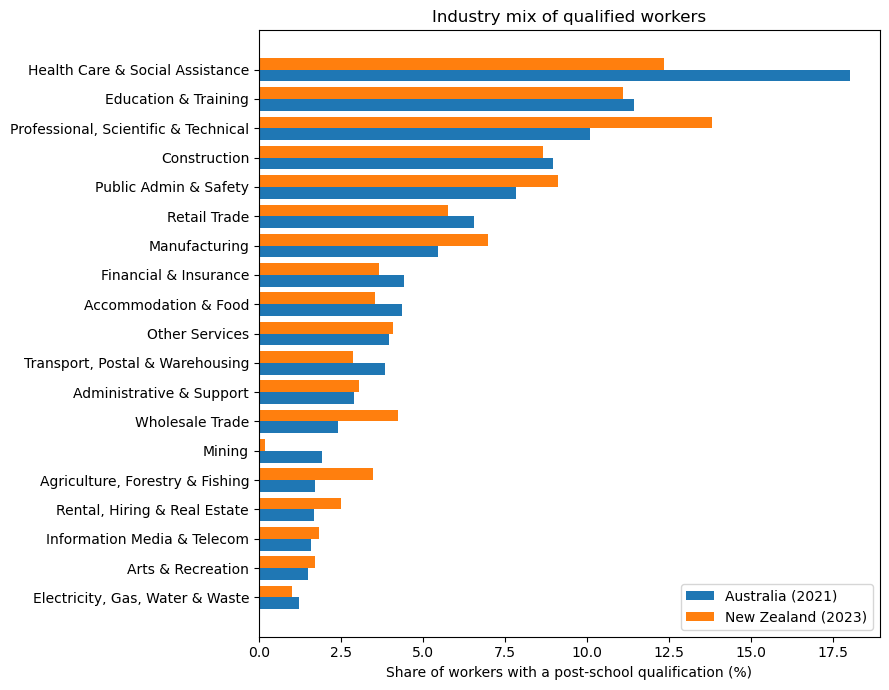

Largest gaps in industry mix (NZ minus Australia, percentage points):


,NZ - AUS (pp)
industry,
Health Care & Social Assistance,-5.7
Mining,-1.7
"Transport, Postal & Warehousing",-1.0
"Agriculture, Forestry & Fishing",1.8
Wholesale Trade,1.8
"Professional, Scientific & Technical",3.7


In [13]:
def compute_measures(counts):
    # Return the industry mix (%), within-industry profile (%) and degree share (%) for both countries
    workers = counts.sum(axis=1)                                            # qualified workers per industry
    mix = workers.groupby(level="country").transform(lambda s: 100 * s / s.sum())
    within = counts.div(workers, axis=0) * 100
    degree = within[DEGREE_GROUPS].sum(axis=1)
    return mix.unstack("country")[COUNTRIES], within, degree.unstack("country")[COUNTRIES]


mix, within, degree = compute_measures(counts)

# Plot 1: industry mix, ordered by the Australian share
order_mix = mix["Australia"].sort_values().index
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(order_mix))
ax.barh(y - 0.2, mix.loc[order_mix, "Australia"], height=0.4, label="Australia (2021)", color="#1f77b4")
ax.barh(y + 0.2, mix.loc[order_mix, "New Zealand"], height=0.4, label="New Zealand (2023)", color="#ff7f0e")
ax.set_yticks(y)
ax.set_yticklabels(order_mix)
ax.set_xlabel("Share of workers with a post-school qualification (%)")
ax.set_title("Industry mix of qualified workers")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

diff_mix = (mix["New Zealand"] - mix["Australia"]).sort_values()
print("Largest gaps in industry mix (NZ minus Australia, percentage points):")
display(pd.concat([diff_mix.head(3), diff_mix.tail(3)]).round(1).to_frame("NZ - AUS (pp)"))

**What the chart shows.** The industry mixes are quite similar. Most industry shares differ by less than 2 percentage points.

Two industries stand out:

- **Health Care & Social Assistance:** 18.0% of Australia's qualified workforce versus 12.3% in NZ.
- **Professional, Scientific & Technical Services:** 10.1% in Australia versus 13.8% in NZ.

So there are some differences, but not enough to suggest that the two qualified workforces are built from completely different industries.

**Important:** these percentages only describe workers in the comparable post-school qualification groups. Section 7 repeats the comparison for the whole workforce.


### 5.2 What qualifications do workers hold within each industry?

The next chart changes the denominator. Instead of asking *where qualified workers work*, it asks:

> **Within one industry, how is its qualified workforce split across qualification levels?**

The stacked bars show the full profile for each country. Industries are ordered by their average degree share, making the high- and low-qualification industries easier to compare.


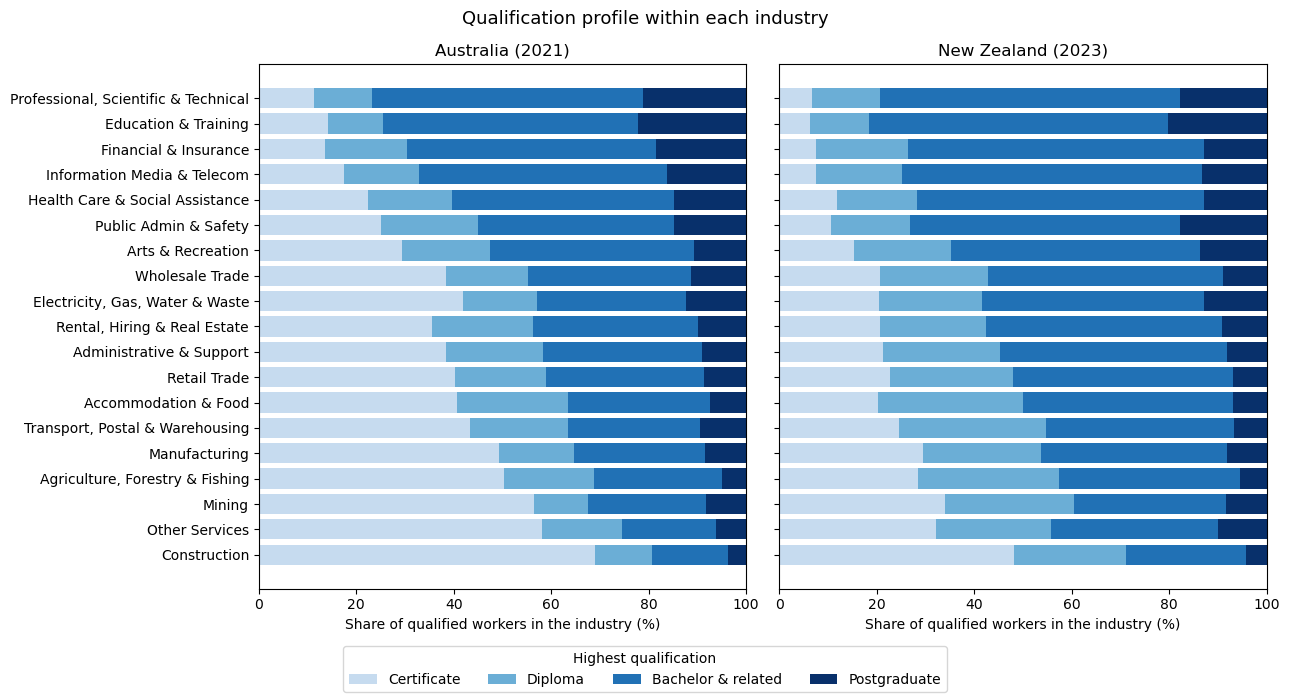

In [14]:
QUAL_COLOURS = {"Certificate": "#c6dbef", "Diploma": "#6baed6",
                "Bachelor & related": "#2171b5", "Postgraduate": "#08306b"}

order_deg = degree.mean(axis=1).sort_values().index        # lowest degree share at the bottom

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
for ax, country in zip(axes, COUNTRIES):
    left = np.zeros(len(order_deg))
    for group in QUAL_GROUPS:
        values = within.loc[country].loc[order_deg, group].to_numpy()
        ax.barh(order_deg, values, left=left, color=QUAL_COLOURS[group], label=group)
        left += values
    ax.set_title(f"{country} ({'2021' if country == 'Australia' else '2023'})")
    ax.set_xlabel("Share of qualified workers in the industry (%)")
    ax.set_xlim(0, 100)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Highest qualification", loc="lower center", ncol=4)
fig.suptitle("Qualification profile within each industry", fontsize=13)
plt.tight_layout(rect=(0, 0.07, 1, 1))     # leave room for the legend at the bottom
plt.show()

The heatmap below turns the same profiles into direct **NZ minus Australia** differences.

- Positive/red values mean that qualification group has a larger share in New Zealand.
- Negative/blue values mean it has a larger share in Australia.
- Each number is a **percentage-point difference**, not a raw count.

This is useful because the stacked bars show the overall shape, while the heatmap makes the size and direction of each country difference explicit.


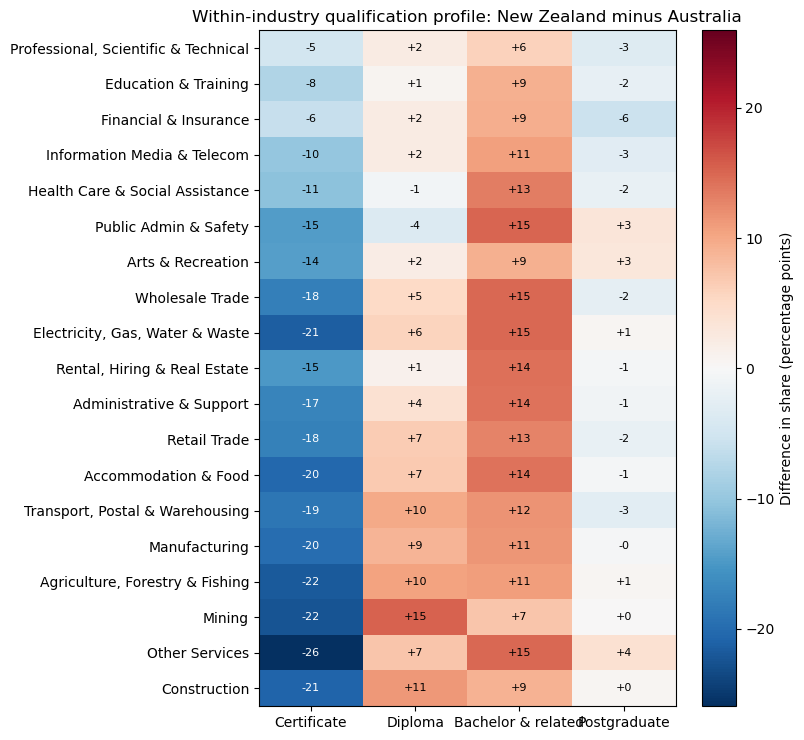

In [15]:
diff_within = (within.loc["New Zealand"] - within.loc["Australia"]).loc[order_deg[::-1], QUAL_GROUPS]

fig, ax = plt.subplots(figsize=(8, 7.5))
limit = diff_within.abs().to_numpy().max()
image = ax.imshow(diff_within.to_numpy(), cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(len(QUAL_GROUPS)))
ax.set_xticklabels(QUAL_GROUPS)
ax.set_yticks(range(len(diff_within)))
ax.set_yticklabels(diff_within.index)
for i in range(diff_within.shape[0]):
    for j in range(diff_within.shape[1]):
        value = diff_within.iloc[i, j]
        ax.text(j, i, f"{value:+.0f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.6 * limit else "black")   # keep text readable on dark cells
ax.set_title("Within-industry qualification profile: New Zealand minus Australia")
fig.colorbar(image, ax=ax, label="Difference in share (percentage points)")
plt.tight_layout()
plt.show()

**What the two graphs show.** The same industries tend to sit at the high and low ends in both countries: professional, education, finance, information and health services are relatively degree-heavy, while construction and other services are less so.

Under the **main certificate mapping**, NZ also appears to have fewer Certificate holders and more Bachelor-level-or-higher workers across many industries. Because this pattern appears almost everywhere rather than in just one or two industries, it may reflect the way certificates are classified rather than a genuine country-wide education difference.

That is why we do not treat this graph alone as the final answer. **Section 6 tests the certificate assumption directly.**


### 5.3 Degree share by industry

To make the comparison easier to read, the next chart reduces each industry's profile to one measure: the percentage of its comparable qualified workforce with a **Bachelor-level or higher qualification**.

The connected points show the gap for each industry directly.

We also calculate:

- **Spearman rank correlation**, which tells us whether the countries rank industries similarly from less to more degree-heavy.
- **Total variation distance**, which summarises how different the full four-category qualification profiles are. A smaller value means the profiles are more alike.


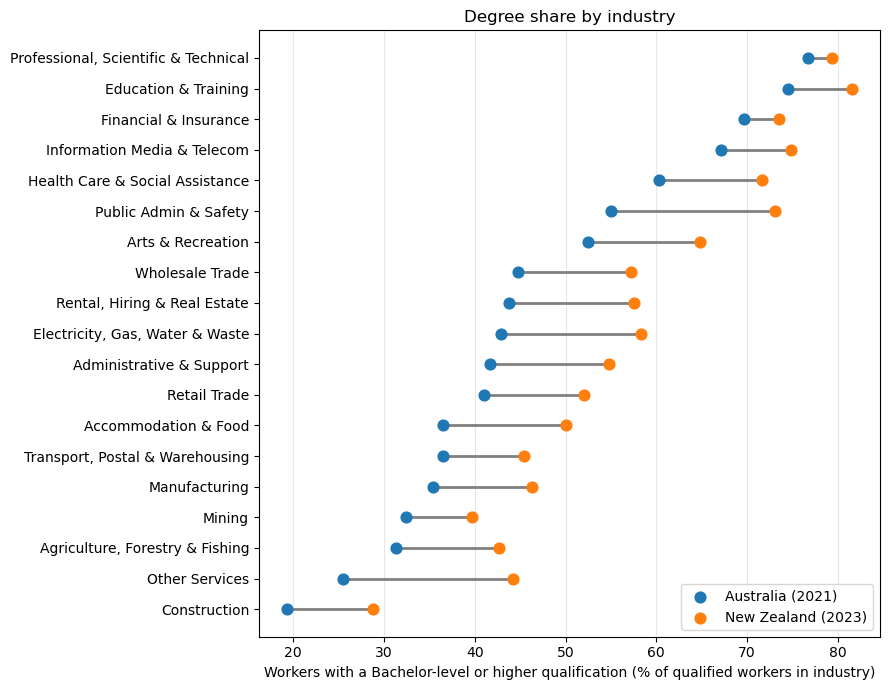

country,Australia,New Zealand,Gap NZ-AUS (pp),Profile distance (%)
industry,,,,
Other Services,25.5,44.2,18.7,25.9
Mining,32.4,39.6,7.2,22.4
"Agriculture, Forestry & Fishing",31.3,42.7,11.4,21.8
"Transport, Postal & Warehousing",36.5,45.4,8.9,21.5
"Electricity, Gas, Water & Waste",42.9,58.4,15.4,21.3
Accommodation & Food,36.5,50.0,13.5,20.9
Construction,19.3,28.8,9.5,20.9
Manufacturing,35.3,46.3,11.0,20.2
Wholesale Trade,44.7,57.3,12.5,20.1


Spearman rank correlation of industry degree shares (AUS vs NZ): 0.98


In [16]:
order_dumb = degree["Australia"].sort_values().index

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(order_dumb))
ax.hlines(y, degree.loc[order_dumb, "Australia"], degree.loc[order_dumb, "New Zealand"], color="grey", lw=2)
ax.scatter(degree.loc[order_dumb, "Australia"], y, color="#1f77b4", s=60, label="Australia (2021)", zorder=3)
ax.scatter(degree.loc[order_dumb, "New Zealand"], y, color="#ff7f0e", s=60, label="New Zealand (2023)", zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(order_dumb)
ax.set_xlabel("Workers with a Bachelor-level or higher qualification (% of qualified workers in industry)")
ax.set_title("Degree share by industry")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Total variation distance between the two qualification profiles of each industry
tvd = 0.5 * (within.loc["Australia"] - within.loc["New Zealand"]).abs().sum(axis=1)
summary = degree.copy()
summary["Gap NZ-AUS (pp)"] = degree["New Zealand"] - degree["Australia"]
summary["Profile distance (%)"] = tvd
display(summary.sort_values("Profile distance (%)", ascending=False).round(1))

rank_corr = degree["Australia"].corr(degree["New Zealand"], method="spearman")
print(f"Spearman rank correlation of industry degree shares (AUS vs NZ): {rank_corr:.2f}")

**What the chart and statistics show.** The two countries rank industries very similarly by degree share (**Spearman 0.98**).

Professional, Scientific & Technical Services, Education & Training, and Financial & Insurance Services are among the most degree-heavy in both countries; Construction is the least degree-heavy.

Under the main mapping, NZ's degree share is higher in every industry. The closest qualification profiles are in Professional Services and Education, while Other Services, Mining and Agriculture differ the most.

The important point is the **ranking**, which is very stable: the type of industry is strongly related to its qualification profile in both countries. The size and even direction of the country gap is less certain because of the certificate mapping, which we test in Section 6.


### 5.4 A simpler view: four broad sectors

Nineteen industries can make the overall structure hard to see. We therefore group them into four broad sectors and compare two things side by side:

1. each sector's share of the qualified workforce; and
2. the percentage of workers in that sector with a Bachelor-level or higher qualification.

This gives a compact view of both **economic structure** and **education intensity**.


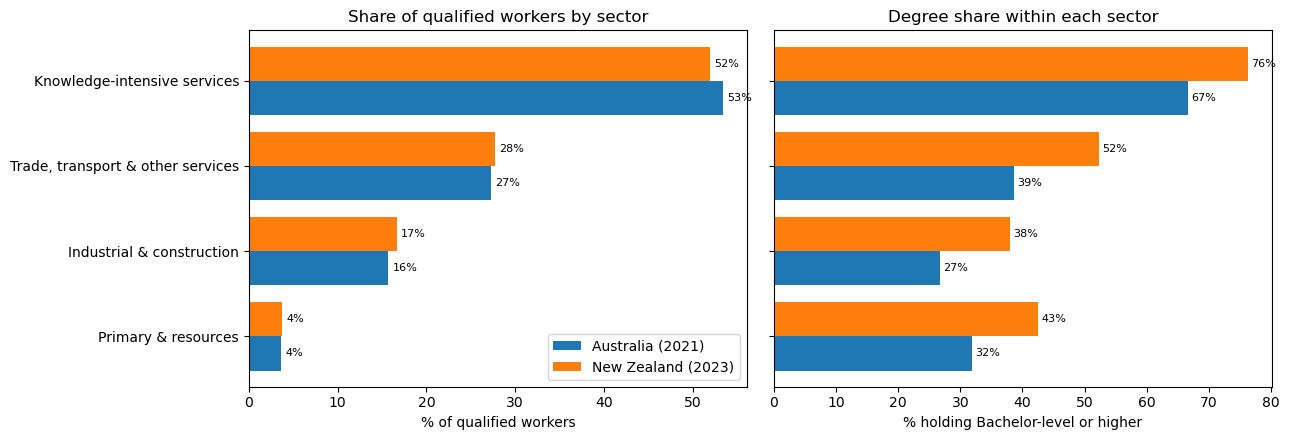

Sector share (%)              \
country                                  Australia New Zealand   
sector                                                           
Primary & resources                            3.6         3.7   
Industrial & construction                     15.7        16.7   
Trade, transport & other services             27.3        27.7   
Knowledge-intensive services                  53.4        51.9   

                                  Degree share (%)              
country                                  Australia New Zealand  
sector                                                          
Primary & resources                           31.9        42.6  
Industrial & construction                     26.8        38.0  
Trade, transport & other services             38.6        52.3  
Knowledge-intensive services                  66.6        76.3

In [17]:
def sector_summary(counts):
    # Sector share of qualified workers (%) and degree share within each sector (%), per country
    frame = counts.copy()
    frame["sector"] = frame.index.get_level_values("industry").map(SECTOR)
    by_sector = frame.groupby([frame.index.get_level_values("country"), "sector"])[QUAL_GROUPS].sum()
    workers = by_sector.sum(axis=1)
    share = workers.groupby(level=0).transform(lambda s: 100 * s / s.sum()).unstack(0)[COUNTRIES].loc[SECTORS]
    deg = (by_sector[DEGREE_GROUPS].sum(axis=1) / workers * 100).unstack(0)[COUNTRIES].loc[SECTORS]
    return share, deg


sector_share, sector_degree = sector_summary(counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
y = np.arange(len(SECTORS))
for ax, table, title, xlabel in [
        (axes[0], sector_share, "Share of qualified workers by sector", "% of qualified workers"),
        (axes[1], sector_degree, "Degree share within each sector", "% holding Bachelor-level or higher")]:
    ax.barh(y - 0.2, table["Australia"], height=0.4, label="Australia (2021)", color="#1f77b4")
    ax.barh(y + 0.2, table["New Zealand"], height=0.4, label="New Zealand (2023)", color="#ff7f0e")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_yticks(y)
    ax.set_yticklabels(SECTORS)
    for country, offset in [("Australia", -0.2), ("New Zealand", 0.2)]:
        for yi, value in zip(y, table[country]):
            ax.text(value + 0.5, yi + offset, f"{value:.0f}%", va="center", fontsize=8)  # value labels
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

display(pd.concat({"Sector share (%)": sector_share, "Degree share (%)": sector_degree}, axis=1).round(1))

**What the sector chart shows.** Among workers with comparable post-school qualifications, the sector mixes are very close.

Knowledge-intensive services account for just over half of qualified workers in both countries (53.4% Australia; 51.9% NZ). The other three sector shares are also close.

The education pattern is also similar: knowledge-intensive services are the most degree-heavy and industrial/construction work is the least.

So, for the **qualified workforce**, there is little evidence that a very different industry structure explains the national qualification gap. However, this comparison still leaves out workers with no post-school qualification. Section 7 adds them back in.


### 5.5 Where does the national degree gap come from?

An overall qualification gap can appear for two different reasons:

- **Industry-mix effect:** one country has more workers in industries that are already degree-heavy.
- **Within-industry effect:** the countries have similar industries, but workers inside the same industry have different qualification levels.

A simple way to think about it: if two countries have identical qualification rates inside each industry but one has more people working in highly educated industries, the gap is a **mix effect**. If their industry shares are the same but qualification rates differ inside those industries, it is a **within-industry effect**.

The function below splits the NZ–Australia degree-share gap into these two components. The two pieces add exactly to the total gap.


Overall degree share of qualified workers: Australia 51.5%, New Zealand 62.0%
Total gap (NZ - AUS): +10.5 pp
   of which mix effect:             +0.2 pp
   of which within-industry effect: +10.3 pp


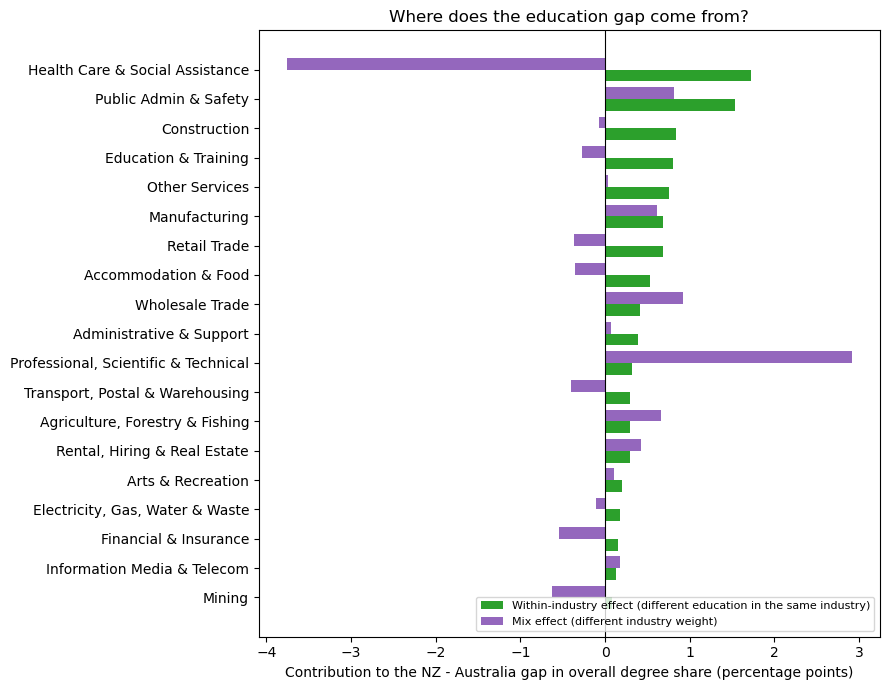

In [18]:
def decompose_gap(mix, degree):
    # Split the NZ-minus-AUS gap in overall degree share (pp) into per-industry mix and within-industry contributions
    w_a, w_n = mix["Australia"] / 100, mix["New Zealand"] / 100
    p_a, p_n = degree["Australia"], degree["New Zealand"]
    contrib = pd.DataFrame({
        "Mix effect": (w_n - w_a) * (p_a + p_n) / 2,          # different industry weights
        "Within-industry effect": (w_a + w_n) / 2 * (p_n - p_a),  # different education inside industry
    })
    total_gap = (w_n * p_n).sum() - (w_a * p_a).sum()
    assert np.isclose(contrib.to_numpy().sum(), total_gap)     # the split is exact
    return contrib, (w_a * p_a).sum(), (w_n * p_n).sum()


contrib, overall_aus, overall_nz = decompose_gap(mix, degree)
print(f"Overall degree share of qualified workers: Australia {overall_aus:.1f}%, New Zealand {overall_nz:.1f}%")
print(f"Total gap (NZ - AUS): {overall_nz - overall_aus:+.1f} pp")
print(f"   of which mix effect:             {contrib['Mix effect'].sum():+.1f} pp")
print(f"   of which within-industry effect: {contrib['Within-industry effect'].sum():+.1f} pp")

order_c = contrib["Within-industry effect"].sort_values().index
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(order_c))
ax.barh(y - 0.2, contrib.loc[order_c, "Within-industry effect"], height=0.4, color="#2ca02c",
        label="Within-industry effect (different education in the same industry)")
ax.barh(y + 0.2, contrib.loc[order_c, "Mix effect"], height=0.4, color="#9467bd",
        label="Mix effect (different industry weight)")
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(order_c)
ax.set_xlabel("Contribution to the NZ - Australia gap in overall degree share (percentage points)")
ax.set_title("Where does the education gap come from?")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation.** Under the main mapping, the overall degree-share gap is **+10.5 percentage points for NZ**. Almost all of it is a **within-industry effect (+10.3 pp)**, while the industry-mix effect is only **+0.2 pp**.

In other words, this version of the data does **not** suggest that NZ's higher degree share comes from having more workers in degree-heavy industries. It appears inside the same industries.

However, this result depends heavily on how certificates are matched. The next section tests that weakness before we draw a final conclusion.


## 6. Sensitivity check: does the certificate assumption change the answer?

The certificate mapping is the least certain part of the comparison. Our main mapping treats **NZ Level 4** as Certificate and excludes Level 3.

For the sensitivity check, we add **NZ Level 3** to the Certificate group and rerun the same code. We are not claiming that this alternative is definitely correct; the purpose is to ask:

> **If a reasonable classification choice changes the result, which conclusions are still safe to make?**


In [19]:
alt_map = {**NZ_QUAL_MAP, "Level 3 certificate": "Certificate"}
mix_alt, within_alt, degree_alt = compute_measures(build_counts(alt_map))
contrib_alt, _, overall_nz_alt = decompose_gap(mix_alt, degree_alt)

change = (degree_alt["New Zealand"] - degree["New Zealand"])
print(f"NZ overall degree share: {overall_nz:.1f}% -> {overall_nz_alt:.1f}% when Level 3 is added")
print(f"Largest change in an industry's NZ degree share: {change.abs().max():.1f} pp ({change.abs().idxmax()})")
print(f"Gap NZ-AUS: {overall_nz - overall_aus:+.1f} pp -> {overall_nz_alt - overall_aus:+.1f} pp "
      f"(mix {contrib_alt['Mix effect'].sum():+.1f}, within {contrib_alt['Within-industry effect'].sum():+.1f})")
print("Spearman rank correlation with alternative mapping:",
      round(degree_alt['Australia'].corr(degree_alt['New Zealand'], method='spearman'), 2))

# Degree-share gap (NZ - AUS, pp) under the two mappings, industry by industry
bounds = pd.DataFrame({"Main mapping (NZ Level 4 only)": degree["New Zealand"] - degree["Australia"],
                       "Alternative (NZ Level 3 + 4)": degree_alt["New Zealand"] - degree_alt["Australia"]})
display(bounds.sort_values("Alternative (NZ Level 3 + 4)").round(1))
print(f"Industries where NZ has a LOWER degree share than Australia: "
      f"main mapping {(bounds.iloc[:, 0] < 0).sum()} of 19, alternative mapping {(bounds.iloc[:, 1] < 0).sum()} of 19")

NZ overall degree share: 62.0% -> 49.5% when Level 3 is added
Largest change in an industry's NZ degree share: 19.5 pp (Retail Trade)
Gap NZ-AUS: +10.5 pp -> -2.0 pp (mix -1.4, within -0.6)
Spearman rank correlation with alternative mapping: 0.91


,Main mapping (NZ Level 4 only),Alternative (NZ Level 3 + 4)
industry,,
Retail Trade,11.0,-8.5
Financial & Insurance,3.9,-7.7
"Professional, Scientific & Technical",2.7,-5.9
Accommodation & Food,13.5,-5.8
Information Media & Telecom,7.7,-4.8
"Transport, Postal & Warehousing",8.9,-3.8
Arts & Recreation,12.3,-3.8
Wholesale Trade,12.5,-1.8
Administrative & Support,13.1,-1.3


Industries where NZ has a LOWER degree share than Australia: main mapping 0 of 19, alternative mapping 13 of 19


### Sensitivity result

The answer changes substantially.

Adding NZ Level 3 certificates lowers NZ's overall degree share from **62.0% to 49.5%**. The NZ–Australia gap therefore changes from **+10.5 pp to −2.0 pp**, and NZ has a lower degree share than Australia in 13 of the 19 industries under this alternative.

This means we should **not** make a strong claim about which country is more degree-qualified overall based on the qualified-workforce comparison alone.

What **does** survive both mappings:

- the industry-mix effect stays small;
- the broad sector shares remain similar; and
- the countries still rank industries similarly by education level.

So the robust result is about **structure and ranking**, not the exact national degree gap. Section 7 uses the whole workforce to get a more complete view.


## 7. Extension: the whole workforce

Sections 5 and 6 only compare workers who fall into post-school qualification categories shared by both censuses. That is useful for a like-for-like comparison, but it does not describe everyone who is employed.

This section adds a fifth group: **No post-school qualification**.

This means school-level or no formal qualification; it does **not** mean “no education”.

### How the extra group is built

**Australia:** ABS G53 gives workers with a non-school qualification, while G54 gives all employed persons in each industry. We estimate:

`No post-school qualification = all employed workers (G54) − workers with a non-school qualification (G53)`

**New Zealand:** we use the published qualification counts and subtract the groups already included in the post-school comparison.

Because NZ Level 3 is still ambiguous, the whole-workforce results are calculated under **both** mappings. This gives a range rather than pretending the classification uncertainty has disappeared.

The code also checks that the derived Australian values are never negative.


In [20]:
import os

# ---- Extra input for Section 7: ABS G54 (employed persons by industry of employment by age, persons columns) ----
ABS_EMPLOYED_FILES = [
    "2021Census_G54A_AUS_AUS.csv",
    "2021Census_G54B_AUS_AUS.csv",
    "2021Census_G54C_AUS_AUS.csv",
    "2021Census_G54D_AUS_AUS.csv",
]   # G54A-D: the table is split over four files
ABS_EMPLOYED_TEMPLATE = "P_{code}_Tot"                # persons, all ages (15+); {code} = G54 industry code
# G54 uses different industry codes from G53, so we map each of our industry labels to its G54 code
ABS_EMPLOYED_CODES = {
    "Agriculture, Forestry & Fishing": "Ag_For_Fshg",
    "Mining": "Mining",
    "Manufacturing": "Manufact",
    "Electricity, Gas, Water & Waste": "El_Gas_Wt_Waste",
    "Construction": "Constru",
    "Wholesale Trade": "WhlesaleTde",
    "Retail Trade": "RetTde",
    "Accommodation & Food": "Accom_food",
    "Transport, Postal & Warehousing": "Trans_post_wrehsg",
    "Information Media & Telecom": "Info_media_teleco",
    "Financial & Insurance": "Fin_Insur",
    "Rental, Hiring & Real Estate": "RtnHir_REst",
    "Professional, Scientific & Technical": "Pro_scien_tec",
    "Administrative & Support": "Admin_supp",
    "Public Admin & Safety": "Public_admin_sfty",
    "Education & Training": "Educ_trng",
    "Health Care & Social Assistance": "HlthCare_SocAs",
    "Arts & Recreation": "Art_recn",
    "Other Services": "Oth_scs",
}
assert set(ABS_EMPLOYED_CODES) == {label for label, *_ in INDUSTRIES}   # all 19 industries covered

NONE_GROUP = "No post-school qualification"
FULL_GROUPS = [NONE_GROUP] + QUAL_GROUPS              # five groups, lowest to highest level


def load_abs_employed(files, code_map, column_template):
    # Return the total employed persons per industry in Australia (label -> count)
    for file in files:
        if not os.path.exists(file):
            raise FileNotFoundError(f"{file} not found: set ABS_EMPLOYED_FILES to the ABS table file(s)")
    wide = pd.concat([pd.read_csv(file, index_col=0) for file in files], axis=1)
    assert not wide.columns.duplicated().any(), "A column appears in more than one ABS file"
    row = wide.loc["AUS"]
    totals = {}
    for label, code in code_map.items():
        column = column_template.format(code=code)
        assert column in row.index, f"Column {column} not found: check ABS_EMPLOYED_TEMPLATE and ABS_EMPLOYED_CODES"
        totals[label] = int(row[column])
    return pd.Series(totals)


def load_nz_stated(file, nz_names=NZ_IND):
    # Return NZ workers with a stated qualification per industry (label -> count)
    raw = pd.read_csv(file)
    stated = raw[(raw["Highest qualification"] == "Total stated - highest qualification")
                 & raw["Industry"].isin(nz_names)]
    return stated.assign(industry=stated["Industry"].map(nz_names)).set_index("industry")["OBS_VALUE"]


def build_full_counts(nz_qual_map=NZ_QUAL_MAP):
    # Return (country, industry) x five qualification groups, adding the 'no post-school' group
    counts = build_counts(nz_qual_map)                 # the four post-school groups from Section 4
    abs_row = read_abs_row(ABS_FILES)
    aus_employed = load_abs_employed(ABS_EMPLOYED_FILES, ABS_EMPLOYED_CODES, ABS_EMPLOYED_TEMPLATE)
    nz_stated = load_nz_stated(NZ_FILE)

    full = counts.copy()
    full[NONE_GROUP] = 0
    for label, abs_code, _, _ in INDUSTRIES:
        # Australia: all employed minus everyone holding a non-school qualification (G53 industry total)
        aus_qualified_total = int(abs_row[f"P_{abs_code}_ToT"])
        full.loc[("Australia", label), NONE_GROUP] = aus_employed[label] - aus_qualified_total
        # New Zealand: everyone with a stated qualification minus those kept in the post-school groups
        nz_kept = counts.loc[("New Zealand", label)].sum()
        full.loc[("New Zealand", label), NONE_GROUP] = nz_stated[label] - nz_kept

    assert (full[NONE_GROUP] >= 0).all(), "Negative count: the ABS tables probably cover different populations"
    return full[FULL_GROUPS]

### 7.1 Building and checking the full-workforce table

We build the table twice:

- **Main mapping:** NZ Level 3 is counted in “no post-school qualification”.
- **Alternative mapping:** NZ Level 3 is counted as Certificate.

The summary output checks the national shares and shows the industries at the high and low ends before we move to the full graph.


In [21]:
full_counts = build_full_counts()               # main mapping
full_counts_alt = build_full_counts(alt_map)    # alternative mapping (NZ Level 3 counted as Certificate)

# The same measure functions as in Section 5 work unchanged, now with five groups
mix_full, within_full, degree_full = compute_measures(full_counts)
mix_full_alt, within_full_alt, degree_full_alt = compute_measures(full_counts_alt)
none_share = within_full[NONE_GROUP].unstack("country")[COUNTRIES]              # % of industry workforce
none_share_alt = within_full_alt[NONE_GROUP].unstack("country")[COUNTRIES]

# National summary under both mappings
summary_rows = []
for mapping_name, table in [("Main", full_counts), ("Alternative (NZ Level 3 = qualified)", full_counts_alt)]:
    for country in COUNTRIES:
        country_totals = table.loc[country].sum()          # counts per qualification group, all industries
        everyone = country_totals.sum()
        summary_rows.append({"Mapping": mapping_name, "Country": country,
                             "Workers in comparison": int(everyone),
                             "No post-school qualification (%)": 100 * country_totals[NONE_GROUP] / everyone,
                             "Bachelor-level or higher (%)": 100 * country_totals[DEGREE_GROUPS].sum() / everyone})
display(pd.DataFrame(summary_rows).round(1))

# Industries with the highest and lowest share without a post-school qualification
check = none_share.copy()
check["NZ alternative"] = none_share_alt["New Zealand"]
print("Share of workers with no post-school qualification (%), by industry:")
display(check.sort_values("Australia", ascending=False).round(1).iloc[[0, 1, 2, -3, -2, -1]])

,Mapping,Country,Workers in comparison,No post-school qualification (%),Bachelor-level or higher (%)
0,Main,Australia,11297143,28.8,36.6
1,Main,New Zealand,2541942,46.8,33.0
2,Alternative (NZ Level 3 = qualified),Australia,11297143,28.8,36.6
3,Alternative (NZ Level 3 = qualified),New Zealand,2541942,33.3,33.0


Share of workers with no post-school qualification (%), by industry:


country,Australia,New Zealand,NZ alternative
industry,,,
Accommodation & Food,54.3,67.6,47.1
Retail Trade,51.2,64.9,43.8
"Agriculture, Forestry & Fishing",49.7,63.2,49.6
Health Care & Social Assistance,15.3,31.7,21.7
"Professional, Scientific & Technical",12.7,26.4,17.5
Education & Training,12.1,24.1,16.1


### 7.2 No post-school qualification by industry

The graph below is designed to show the uncertainty directly.

- The **Australian dot** is one estimated value.
- The **New Zealand bar** spans the result under the two Level 3 treatments.

If the Australian dot falls inside the NZ range, the comparison for that industry depends on the certificate assumption. If it sits outside the range, the direction of the difference is robust to both mappings.


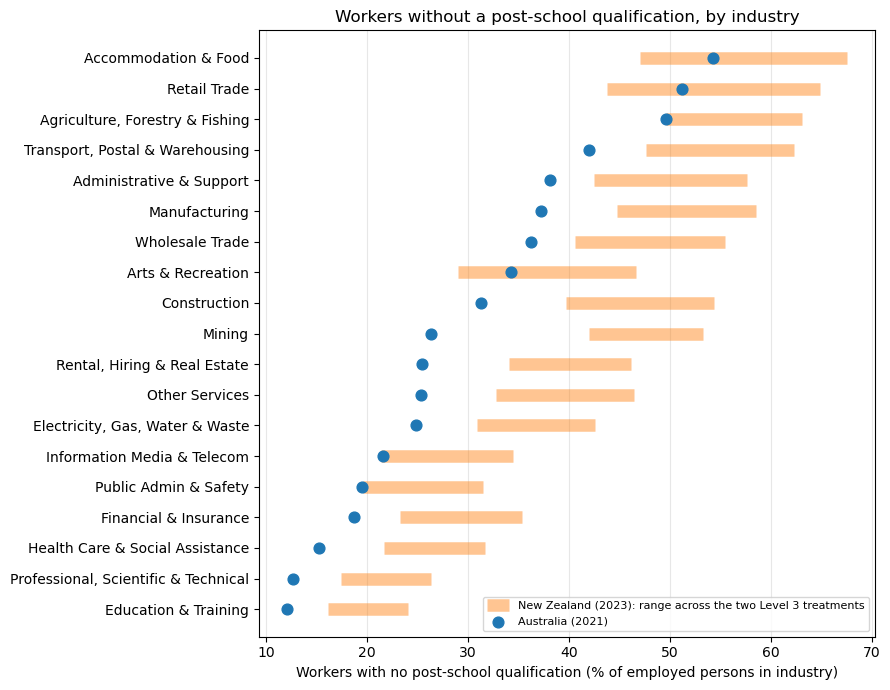

Industries where the Australian share lies inside the New Zealand range: 5 of 19
Spearman rank correlation of the industry shares (AUS vs NZ): main 0.98, alternative 0.93


In [22]:
order_none = none_share["Australia"].sort_values().index
y = np.arange(len(order_none))

fig, ax = plt.subplots(figsize=(9, 7))
ax.hlines(y, none_share_alt.loc[order_none, "New Zealand"], none_share.loc[order_none, "New Zealand"],
          color="#ff7f0e", alpha=0.45, lw=9, label="New Zealand (2023): range across the two Level 3 treatments")
ax.scatter(none_share.loc[order_none, "Australia"], y, color="#1f77b4", s=60, zorder=3, label="Australia (2021)")
ax.set_yticks(y)
ax.set_yticklabels(order_none)
ax.set_xlabel("Workers with no post-school qualification (% of employed persons in industry)")
ax.set_title("Workers without a post-school qualification, by industry")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

inside = 0
for industry in none_share.index:
    low = min(none_share.loc[industry, "New Zealand"], none_share_alt.loc[industry, "New Zealand"])
    high = max(none_share.loc[industry, "New Zealand"], none_share_alt.loc[industry, "New Zealand"])
    if low <= none_share.loc[industry, "Australia"] <= high:
        inside += 1
print(f"Industries where the Australian share lies inside the New Zealand range: {inside} of {len(none_share)}")
print("Spearman rank correlation of the industry shares (AUS vs NZ): "
      f"main {none_share['Australia'].corr(none_share['New Zealand'], method='spearman'):.2f}, "
      f"alternative {none_share['Australia'].corr(none_share_alt['New Zealand'], method='spearman'):.2f}")

**What the graph shows.** The same industries tend to have high or low shares in both countries.

Accommodation & Food, Retail Trade and Agriculture are among the highest; Education, Professional Services and Health Care are among the lowest. The country rankings are therefore very similar (**Spearman 0.98 under the main mapping and 0.93 under the alternative**).

More importantly, the Australian value falls inside the NZ range in only **5 of 19 industries**. In the other 14, NZ has the higher share with no post-school qualification under either mapping.

This is a stronger result than the degree comparison in Section 6 because the **direction** no longer flips when Level 3 is reclassified.


### 7.3 Does the whole-workforce gap come from industry mix?

We now repeat the two questions from Section 5 using **all workers**:

1. Are the countries' industry mixes still similar?
2. Is the gap in “no post-school qualification” mainly caused by different industries, or by differences **within the same industries**?

The same decomposition function is reused, which keeps the method consistent across the report.


Share of qualified workers (%), Section 5.4  \
country                                                             Australia   
sector                                                                          
Primary & resources                                                       3.6   
Industrial & construction                                                15.7   
Trade, transport & other services                                        27.3   
Knowledge-intensive services                                             53.4   

                                              Share of all workers (%)  \
country                           New Zealand                Australia   
sector                                                                   
Primary & resources                       3.7                      4.3   
Industrial & construction                16.7                     16.7   
Trade, transport & other services        27.7                     34.2   
Knowledge-intensive services             51.9                     44.9   

                                               \
country                           New Zealand   
sector                                          
Primary & resources                       5.3   
Industrial & construction                20.0   
Trade, transport & other services        35.7   
Knowledge-intensive services             39.0   

                                  No post-school qualification (%), main  \
country                                                        Australia   
sector                                                                     
Primary & resources                                                 39.5   
Industrial & construction                                           33.1   
Trade, transport & other services                                   43.2   
Knowledge-intensive services                                        15.3   

                                               \
country                           New Zealand   
sector                                          
Primary & resources                      62.7   
Industrial & construction                55.7   
Trade, transport & other services        58.6   
Knowledge-intensive services             29.2   

                                  No post-school qualification (%), alternative  \
country                                                               Australia   
sector                                                                            
Primary & resources                                                        39.5   
Industrial & construction                                                  33.1   
Trade, transport & other services                                          43.2   
Knowledge-intensive services                                               15.3   

                                               
country                           New Zealand  
sector                                         
Primary & resources                      49.3  
Industrial & construction                41.6  
Trade, transport & other services        41.6  
Knowledge-intensive services             19.2

Main mapping: no post-school qualification is 28.8% in Australia and 46.8% in New Zealand (gap +17.9 pp = mix +1.3 + within-industry +16.6)
Alternative mapping: no post-school qualification is 28.8% in Australia and 33.3% in New Zealand (gap +4.4 pp = mix +1.3 + within-industry +3.2)


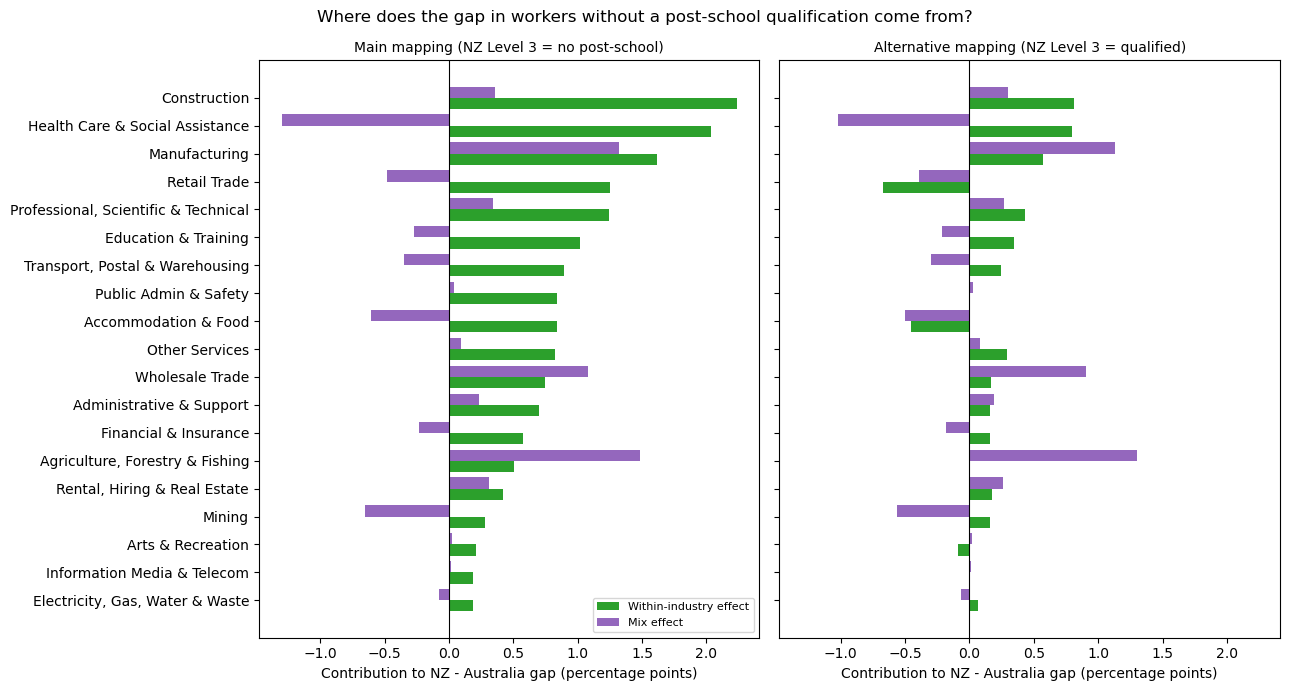

In [23]:
def sector_full_summary(full_table):
    # Sector share of all workers (%) and share with no post-school qualification within each sector (%)
    frame = full_table.copy()
    frame["sector"] = frame.index.get_level_values("industry").map(SECTOR)
    by_sector = frame.groupby([frame.index.get_level_values("country"), "sector"])[FULL_GROUPS].sum()
    workers = by_sector.sum(axis=1)
    share = workers.groupby(level=0).transform(lambda s: 100 * s / s.sum()).unstack(0)[COUNTRIES].loc[SECTORS]
    none = (by_sector[NONE_GROUP] / workers * 100).unstack(0)[COUNTRIES].loc[SECTORS]
    return share, none


sector_share_full, sector_none = sector_full_summary(full_counts)
_, sector_none_alt = sector_full_summary(full_counts_alt)
display(pd.concat({"Share of qualified workers (%), Section 5.4": sector_share,
                   "Share of all workers (%)": sector_share_full,
                   "No post-school qualification (%), main": sector_none,
                   "No post-school qualification (%), alternative": sector_none_alt}, axis=1).round(1))

# Decomposition of the NZ - Australia gap in the share with no post-school qualification
contrib_main, none_aus, none_nz_main = decompose_gap(mix_full, none_share)
contrib_alt, _, none_nz_alt = decompose_gap(mix_full_alt, none_share_alt)
for name, contrib_table, nz_value in [("Main mapping", contrib_main, none_nz_main),
                                      ("Alternative mapping", contrib_alt, none_nz_alt)]:
    print(f"{name}: no post-school qualification is {none_aus:.1f}% in Australia and {nz_value:.1f}% in New Zealand "
          f"(gap {nz_value - none_aus:+.1f} pp = mix {contrib_table['Mix effect'].sum():+.1f} "
          f"+ within-industry {contrib_table['Within-industry effect'].sum():+.1f})")

order_full = contrib_main["Within-industry effect"].sort_values().index
y = np.arange(len(order_full))
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True, sharex=True)
for ax, contrib_table, title in [(axes[0], contrib_main, "Main mapping (NZ Level 3 = no post-school)"),
                                 (axes[1], contrib_alt, "Alternative mapping (NZ Level 3 = qualified)")]:
    ax.barh(y - 0.2, contrib_table.loc[order_full, "Within-industry effect"], height=0.4, color="#2ca02c",
            label="Within-industry effect")
    ax.barh(y + 0.2, contrib_table.loc[order_full, "Mix effect"], height=0.4, color="#9467bd", label="Mix effect")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Contribution to NZ - Australia gap (percentage points)")
axes[0].set_yticks(y)
axes[0].set_yticklabels(order_full)
axes[0].legend(loc="lower right", fontsize=8)
fig.suptitle("Where does the gap in workers without a post-school qualification come from?", fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation.**

First, the full-workforce sector mix differs a little more than the qualified-only mix. Knowledge-intensive services account for **44.9%** of Australian workers and **39.0%** of NZ workers. The difference is noticeable, but still smaller than the qualification gaps.

Second, Australia has **28.8%** of workers with no post-school qualification. NZ ranges from **33.3% to 46.8%**, depending on the Level 3 treatment.

The decomposition tells the more important story:

- **Mix effect:** about **+1.3 pp** under either mapping.
- **Within-industry effect:** **+3.2 to +16.6 pp**, depending on the mapping.

So the exact size is uncertain, but the conclusion is stable: **most of the gap occurs within industries rather than because the two countries have very different industry mixes.**


### 7.4 Postgraduate qualifications across the whole workforce

The previous graph looked at the lower end of the qualification scale. This final comparison looks at the top: **postgraduate degrees as a percentage of all workers in each industry**.

This is especially useful because the result does **not** depend on how NZ Level 3 certificates are classified. Level 3 can move between Certificate and “no post-school qualification”, but it can never become Postgraduate.

That makes this the cleanest qualification comparison in the report.


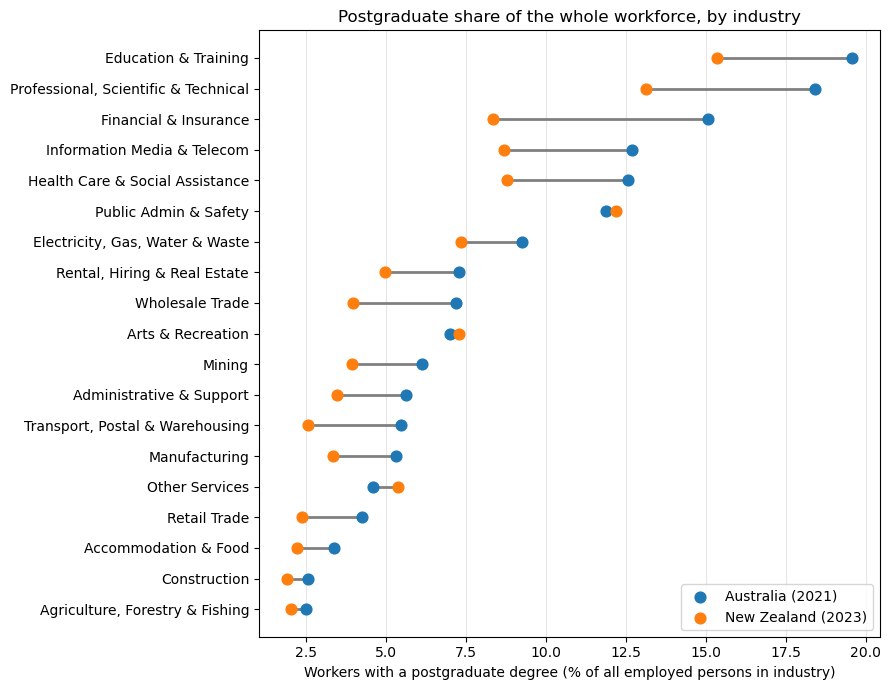

Postgraduate share of all workers: Australia 9.4%, New Zealand 6.5%
Gap (NZ - AUS): -2.8 pp = mix -0.4 + within-industry -2.4
Industries where NZ's postgraduate share is LOWER than Australia's: 16 of 19
Spearman rank correlation of industry postgraduate shares (AUS vs NZ): 0.93


country,Australia,New Zealand
industry,,
Education & Training,19.6,15.3
"Professional, Scientific & Technical",18.4,13.1
Financial & Insurance,15.1,8.4
Information Media & Telecom,12.7,8.7
Health Care & Social Assistance,12.6,8.8
Public Admin & Safety,11.9,12.2
"Electricity, Gas, Water & Waste",9.2,7.4
"Rental, Hiring & Real Estate",7.3,5.0
Wholesale Trade,7.2,4.0


In [24]:
postgrad_share = within_full["Postgraduate"].unstack("country")[COUNTRIES]   # % of ALL workers in the industry

order_pg = postgrad_share["Australia"].sort_values().index
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(order_pg))
ax.hlines(y, postgrad_share.loc[order_pg, "Australia"], postgrad_share.loc[order_pg, "New Zealand"], color="grey", lw=2)
ax.scatter(postgrad_share.loc[order_pg, "Australia"], y, color="#1f77b4", s=60, label="Australia (2021)", zorder=3)
ax.scatter(postgrad_share.loc[order_pg, "New Zealand"], y, color="#ff7f0e", s=60, label="New Zealand (2023)", zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(order_pg)
ax.set_xlabel("Workers with a postgraduate degree (% of all employed persons in industry)")
ax.set_title("Postgraduate share of the whole workforce, by industry")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# National postgraduate share and its mix / within-industry decomposition (mapping-independent)
contrib_pg, pg_aus, pg_nz = decompose_gap(mix_full, postgrad_share)
print(f"Postgraduate share of all workers: Australia {pg_aus:.1f}%, New Zealand {pg_nz:.1f}%")
print(f"Gap (NZ - AUS): {pg_nz - pg_aus:+.1f} pp = mix {contrib_pg['Mix effect'].sum():+.1f} "
      f"+ within-industry {contrib_pg['Within-industry effect'].sum():+.1f}")
print(f"Industries where NZ's postgraduate share is LOWER than Australia's: "
      f"{(postgrad_share['New Zealand'] < postgrad_share['Australia']).sum()} of {len(postgrad_share)}")
print("Spearman rank correlation of industry postgraduate shares (AUS vs NZ):",
      round(postgrad_share["Australia"].corr(postgrad_share["New Zealand"], method="spearman"), 2))

display(postgrad_share.round(1).sort_values("Australia", ascending=False))

**What the graph shows.** NZ has a lower postgraduate share than Australia in **16 of 19 industries**, while the countries still rank industries similarly (**Spearman 0.93**).

Nationally:

- **Australia:** 9.4% of all workers hold a postgraduate degree.
- **New Zealand:** 6.5%.
- **Gap (NZ − AUS): −2.8 percentage points.**

The decomposition again shows that the gap is mainly **within industries (−2.4 pp)** rather than an industry-mix effect (−0.4 pp).

Because this measure is unaffected by the Level 3 certificate uncertainty, it provides the strongest evidence in this notebook for a genuine country difference at the **postgraduate** level.


## 8. Conclusions and limitations

### 8.1 Answer to the research question

This project asked:

> **How do the post-school qualification profiles of the Australian (2021) and New Zealand (2023) workforces differ across industries, from no post-school qualification to postgraduate degree? Are the differences mainly explained by the industries that employ people in each country, or by differences in qualification levels within the same industries?**

Overall, the results show that **Australia and New Zealand have broadly similar industry structures, but their qualification profiles differ within those industries**.

The clearest result is at the postgraduate level. Across the whole workforce, **9.4% of Australian workers hold a postgraduate qualification compared with 6.5% of New Zealand workers**. Using the underlying values, this gives a gap of about **2.8 percentage points in Australia's favour**. Australia also has a higher postgraduate share in **16 of the 19 industries examined**.

By contrast, the comparison is less certain around certificates, diplomas and Bachelor-level qualifications. This is because the Australian **Certificate I-IV** category does not align exactly with New Zealand's Level 3 and Level 4 qualification categories. Depending on how New Zealand Level 3 is classified, the estimated Bachelor-level-or-higher gap can even change direction.

The analysis also shows that the overall difference is **not mainly caused by the two countries having different mixes of industries**. Across the decompositions used in this project, the industry-mix effect is small. Most of the difference comes from **workers within the same industries having different qualification profiles**.

The main results are summarised below.

| **Measure** | **Australia** | **New Zealand** | **NZ - AUS** | **Effect of NZ Level 3 assumption** |
|---|---:|---:|---:|---|
| Bachelor-level or higher, qualified workers | 51.5% | 49.5%-62.0% | -2.0 to +10.5 pp | **Direction changes** |
| No post-school qualification, whole workforce | 28.8% | 33.3%-46.8% | +4.4 to +17.9 pp | **Size changes, direction does not** |
| Postgraduate qualification, whole workforce | 9.4% | 6.5% | -2.8 pp | **Unaffected** |

This table shows that the strength of the Australia-New Zealand comparison depends on which part of the qualification scale is examined. The postgraduate result is the most robust, while the Bachelor-level and no-post-school comparisons are more sensitive to the treatment of New Zealand Level 3 qualifications.

---

### 8.2 Finding 1 - The two countries have broadly similar industry structures

Sections **5.1, 5.4 and 7.3** compared how workers are distributed across industries and broader sectors.

Among workers with post-school qualifications, the sector distributions are very similar. The sector shares differ by no more than about **1.5 percentage points**.

When the analysis is extended to the whole workforce, the differences become slightly larger. For example, knowledge-intensive services account for approximately:

- **44.9% of the Australian workforce**
- **39.0% of the New Zealand workforce**

This difference is noticeable, but it is still relatively small compared with the qualification gaps observed within industries.

The main point is that the two countries are **not being compared across completely different employment structures**. Their workers are distributed across broadly similar types of industries.

This means that differences in national qualification levels cannot simply be explained by one country having a much larger share of workers in highly educated industries.

---

### 8.3 Finding 2 - The same industries tend to have similar qualification patterns in both countries

Sections **5.2, 5.3, 7.2 and 7.4** compared qualification patterns industry by industry.

A consistent pattern appears in both countries. Industries such as:

- Professional, Scientific and Technical Services
- Education and Training
- Financial and Insurance Services
- Information Media and Telecommunications
- Health Care and Social Assistance

tend to have relatively high shares of workers with Bachelor-level and postgraduate qualifications.

By contrast, industries such as:

- Construction
- Accommodation and Food Services

tend to have lower shares.

The industry rankings are highly similar across Australia and New Zealand, with **Spearman rank correlations ranging from about 0.91 to 0.98** across the measures examined.

This does not mean that the percentages are identical. Instead, it means that industries that rank as highly qualified in Australia also tend to rank highly in New Zealand, while industries with lower qualification shares tend to appear in similar positions in both countries.

A careful interpretation is therefore:

> **Industry is strongly associated with the qualification profile of its workforce in both countries, and the broad pattern across industries is very similar.**

---

### 8.4 Finding 3 - Most of the national qualification difference comes from within industries

The decomposition analyses in Sections **5.5, 6, 7.3 and 7.4** separate the overall difference into two parts:

1. **Industry-mix effect** - the difference caused by the two countries having different proportions of workers in each industry.
2. **Within-industry effect** - the difference caused by workers in the same industry having different qualification profiles across countries.

Across the decompositions used in this report, the industry-mix effect is small, ranging from approximately **-1.4 to +1.3 percentage points**.

The larger component is the **within-industry effect**.

This is one of the most important findings of the project.

For example, if Australia simply had many more workers in professional services and far fewer workers in construction, that alone could produce a higher national degree share. However, the decomposition shows that this is not the main explanation.

Instead, workers in comparable industries have different qualification profiles in the two countries.

The most accurate interpretation is therefore:

> **The overall qualification gap is mainly a within-industry difference, not a result of Australia and New Zealand having very different industry structures.**

---

### 8.5 Finding 4 - The answer changes depending on which qualification level is examined

The results are clearer when the qualification scale is considered in separate parts.

#### Bachelor-level or higher among qualified workers

Australia has a Bachelor-level-or-higher share of **51.5%** among qualified workers.

For New Zealand, the estimate ranges from approximately **49.5% to 62.0%**, depending on how Level 3 qualifications are treated.

This produces a gap ranging from:

- approximately **2.0 percentage points in Australia's favour**, to
- approximately **10.5 percentage points in New Zealand's favour**.

Because the direction of the result can change under different reasonable assumptions, this comparison is **not robust**.

It would therefore be misleading to make a firm statement that either country has the higher Bachelor-level-or-higher share among qualified workers.

#### No post-school qualification

For the whole workforce, approximately **28.8% of Australian workers** are estimated to have no post-school qualification.

For New Zealand, the estimate ranges from approximately **33.3% to 46.8%**.

Unlike the Bachelor-level result, the direction does not change. Under both assumptions, New Zealand has a higher share of workers with no post-school qualification.

However, the **size of the gap changes substantially**, from about:

- **4.4 percentage points**, to
- **17.9 percentage points**.

The safest conclusion is therefore that **New Zealand has a higher estimated share of workers without a post-school qualification**, although the exact size of that difference depends on how Level 3 qualifications are classified.

#### Postgraduate qualifications

The postgraduate comparison is much clearer.

Across the whole workforce:

- **Australia: 9.4%**
- **New Zealand: 6.5%**

The underlying calculation gives a gap of about **2.8 percentage points in Australia's favour**.

This result is not affected by the Level 3 classification issue.

Australia also has a higher postgraduate share in **16 of the 19 industries examined**.

The decomposition shows that this difference is mainly a **within-industry effect**, rather than a consequence of Australia simply having more workers in postgraduate-intensive industries.

For this reason, the postgraduate result is the **most robust cross-country comparison in this project**.

---

### 8.6 What can be concluded confidently?

The results do **not** support one simple statement that one country has a uniformly "more educated" workforce.

Instead, they support several more precise conclusions.

First, **Australia and New Zealand have broadly similar industry structures**. Differences in where people work exist, but they are not large enough to explain most of the qualification gap.

Second, **the same industries tend to have similar relative qualification patterns in both countries**. Industries with high degree or postgraduate shares in Australia usually also rank highly in New Zealand.

Third, **most of the difference comes from within industries**. Workers in comparable industries have different qualification profiles across the two countries.

Fourth, the strength of the result depends on the qualification level being examined.

The **postgraduate result is robust**: Australia has a higher postgraduate share overall and in most industries studied.

The comparison around **certificates, diplomas and Bachelor-level qualifications is less certain**, because the two census systems do not classify qualifications in exactly the same way.

A careful overall conclusion is therefore:

> **Australia and New Zealand have broadly similar employment structures, but different qualification profiles within those structures. The strongest evidence is that Australia has a higher postgraduate share, while comparisons around certificate, diploma and Bachelor-level qualifications remain sensitive to how New Zealand Level 3 qualifications are classified.**

---

## 8.7 Limitations

### 1. Different census years and conditions

The Australian data comes from the **2021 Census**, while the New Zealand data comes from the **2023 Census**.

This means the comparison is not between exactly the same point in time.

The analysis assumes that the overall relationship between industry and qualification levels did not change enough between 2021 and 2023 to invalidate the comparison.

This assumption cannot be tested directly using the datasets in this project.

The results should therefore be interpreted as a comparison between **Australia in 2021 and New Zealand in 2023**, rather than a perfectly simultaneous comparison.

### 2. Qualification classifications do not match exactly

The largest limitation is the difference between the qualification systems used by the two censuses.

The Australian data includes a broad **Certificate I-IV** category, while New Zealand separates qualifications into Level 3, Level 4 and other categories.

These categories are related, but they are not exact equivalents.

The treatment of New Zealand Level 3 is especially important because it affects whether some workers are classified as having a post-school qualification.

Rather than choosing one mapping and treating it as definitely correct, Sections **6 and 7.3** test multiple reasonable assumptions.

The sensitivity analysis shows that:

- the Bachelor-level-or-higher comparison can **change direction**;
- the no-post-school qualification gap can **change considerably in size**;
- the postgraduate result is **unchanged**.

This is the main reason why the project avoids making one overall ranking of the two workforces.

### 3. Australia's "no post-school qualification" group is derived

The Australian G53 table contains workers with non-school qualifications, but it does not directly provide a complete group for workers with no post-school qualification.

Section 7 therefore estimates this group using:

> **Total employed population from G54 - workers with non-school qualifications from G53**

This allows the analysis to extend from qualified workers to the whole workforce.

However, this value is **derived rather than directly published as one category**.

The project checks that the subtraction produces non-negative and reasonable counts, but it does not independently confirm that the population definitions in G53 and G54 are perfectly identical.

The whole-workforce estimates should therefore be interpreted with slightly more caution than values taken directly from a single table.

### 4. Association, not causation

The census data is cross-sectional.

It shows workers' industries and qualifications at one point in time, but it does not explain why workers entered particular industries or why they obtained particular qualifications.

The analysis can therefore show that industry and qualification profiles are **associated**, but it cannot show that one causes the other.

Other factors may influence the relationship, including occupation, age, migration, professional requirements, labour-market conditions and differences between the two education systems.

These factors are outside the scope of this project.

### 5. The four-sector grouping is analyst-defined

Sections **5.4 and 7.3** group the 19 industries into four broader sectors to make the overall structure easier to compare.

This helps reveal broad patterns that are difficult to see when all 19 industries are considered separately.

However, this four-sector grouping is an analytical choice made for this project rather than an official census classification.

Different reasonable groupings could produce slightly different sector-level results.

For this reason, the sector analysis is used alongside, rather than instead of, the individual-industry analysis.

### 6. Census confidentiality adjustments

Both census agencies adjust small counts to protect confidentiality.

The ABS applies random perturbation, while Stats NZ rounds counts to multiples of three.

This means that some individual counts are not exact.

However, the checks in Section 4 show that these adjustments are very small relative to the national-level totals used in the analysis.

They are therefore unlikely to materially affect the main conclusions.

---

## 8.8 What additional data would resolve the main uncertainty?

The main unresolved issue is the treatment of New Zealand Level 3 qualifications.

Ideally, the New Zealand data would separate Level 3 qualifications into categories that clearly distinguish between:

- school-level qualifications, and
- post-school or trade qualifications that are more comparable with Australian certificates.

With that information, the analysis could align the two qualification systems more directly.

Sections **6 and 7.3** could then report a **single estimate instead of a range**, and the Bachelor-level and no-post-school comparisons could be interpreted with much greater confidence.

This would not materially affect the postgraduate analysis, because postgraduate qualifications are already sufficiently comparable across the two datasets.

---

## 8.9 Final takeaway

The clearest finding of this project is that **industry structure alone does not explain the qualification differences between Australia and New Zealand**.

The two countries employ workers across broadly similar industries, and the same industries tend to have similar relative qualification patterns.

The important differences occur **within those industries**.

At the top of the qualification scale, the result is clear: **Australia has a higher postgraduate share overall and across most industries examined**.

At the middle of the qualification scale, the comparison is less certain because the Australian and New Zealand certificate systems do not align perfectly.

The overall conclusion is therefore:

> **Australia and New Zealand have similar employment structures, but different qualification profiles within those structures. Some differences - especially the postgraduate gap - are robust, while others depend on how the two countries' qualification systems are made comparable.**


## 9. References

Australian Bureau of Statistics. (2021). *Census of Population and Housing: General Community Profile, Tables G53 and G54* [Data set]. ABS Census DataPacks.

Stats NZ. (2023). *2023 Census: Highest qualification, industry, and gender for the employed census usually resident population count aged 15 years and over* [Data set]. Aotearoa Data Explorer.
